# 16 - What-if Simulation Analysis

## Objective

This notebook presents a scenario-based *What-if Simulation Analysis* using the final Full Multimodal XGBoost classifier developed throughout this project.

Unlike the previous evaluation notebooks, the objective is not to assess predictive performance, but rather to investigate how controlled modifications of participant characteristics influence the predictions generated by the trained model.

The complete processed dataset is used as a repository of representative participant profiles. Individual participants can be selected as baseline cases, after which demographic variables, questionnaire responses, or wearable movement features are systematically modified to generate hypothetical clinical scenarios.

The objectives of this notebook are to:

- establish baseline predictions for representative participants using the final Full Multimodal XGBoost classifier;
- simulate clinically meaningful modifications of questionnaire responses, demographic variables, and wearable movement features;
- quantify changes in predicted probabilities for Healthy Controls (HC), Parkinson's Disease (PD), and Other Movement Disorders (OMD);
- investigate the sensitivity of the proposed framework to different groups of input variables;
- provide the computational foundation for the interactive What-if Simulator included in the Streamlit prototype.

The simulated scenarios are intended exclusively to explore the behavior of the trained machine learning model. They do not represent causal relationships, disease progression, treatment response, or clinical recommendations. Instead, they provide an intuitive interpretation of model sensitivity by illustrating how hypothetical changes in participant characteristics influence probabilistic predictions.

## Importing Libraries and Setting Paths

The required libraries are imported, and the project directories are configured. The final Full Multimodal XGBoost model, processed datasets, and output folders are loaded to perform the scenario-based simulation analysis. Dedicated directories are created to store simulation figures and summary tables generated throughout this notebook.

In [1]:
from pathlib import Path

import copy
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PROJECT PATHS
ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)
DATA_DIR = ROOT / "data" / "processed"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs" / "simulation"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: c:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease


## Loading the Final Model and Complete Dataset

The final Full Multimodal XGBoost classifier and the complete processed participant dataset are loaded.

Unlike the previous evaluation notebooks, which exclusively used the independent participant-level test set, this notebook uses the complete processed dataset because the objective is to perform interactive scenario-based simulations rather than estimate predictive performance.

Each participant can therefore serve as the baseline for one or more hypothetical simulation scenarios.

In [2]:
MODEL_PATH = MODEL_DIR / "full_multimodal_xgboost.joblib"
model = joblib.load(MODEL_PATH)
DATASET_PATH = DATA_DIR / "multimodal_full_task_aware.csv"
dataset = pd.read_csv(DATASET_PATH)
X = dataset[model.feature_names_in_].copy()
y = dataset["label"].copy()
print("Model:", MODEL_PATH.name)
print("Dataset:", DATASET_PATH.name)
print("Participants:", len(dataset))
print("Features:", X.shape[1])
print("Classes:", model.classes_)

Model: full_multimodal_xgboost.joblib
Dataset: multimodal_full_task_aware.csv
Participants: 469
Features: 2405
Classes: [0 1 2]


## Generating Baseline Predictions

Baseline predictions are generated for every participant in the complete processed dataset.

These predictions serve as the reference point for all subsequent simulations. During the What-if Analysis, hypothetical modifications will be applied to individual participant profiles while keeping all remaining variables unchanged. The resulting changes in predicted probabilities will then be compared with these baseline predictions.

In [3]:
# BASELINE PREDICTIONS
predictions = model.predict(X)
probabilities = model.predict_proba(X)
confidence = probabilities.max(axis=1)
results = dataset.copy()
results["predicted_label"] = predictions
results["confidence"] = confidence
results["correct_prediction"] = (
    results["label"] == results["predicted_label"]
)
results.head()

,patient_id,CrossArms_Left_AccX_Mean,CrossArms_Right_AccX_Mean,DrinkGlas_Left_AccX_Mean,DrinkGlas_Right_AccX_Mean,Entrainment_Left_AccX_Mean,Entrainment_Right_AccX_Mean,HoldWeight_Left_AccX_Mean,HoldWeight_Right_AccX_Mean,LiftHold_Left_AccX_Mean,...,weight_kg,gender,handedness,family_history_any,family_history_first_degree,alcohol_effect_on_tremor,duplicate_patient_id,predicted_label,confidence,correct_prediction
0,1,-0.000278,0.000139,0.000321,0.000390,0.000133,-0.000149,1.428852e-04,0.000059,-0.000554,...,78.0,Male,Right,Yes,Yes,Unknown,False,0,0.960139,True
1,2,-0.000024,-0.000415,0.003220,0.000288,-0.000354,-0.000638,1.848333e-04,-0.000127,-0.000429,...,104.0,Male,Right,No,Unknown,No Effect,False,2,0.945511,True
2,3,0.000742,-0.001091,-0.000721,0.000872,-0.000234,-0.000184,6.338518e-07,-0.000125,-0.001485,...,78.0,Female,Right,No,Unknown,Unknown,False,0,0.400021,True
3,4,0.000627,-0.001188,-0.000406,0.000204,-0.000192,-0.000285,7.054171e-05,0.000231,-0.000454,...,90.0,Female,Right,No,Unknown,No Effect,False,1,0.957749,True
4,5,-0.000261,-0.001369,-0.000220,-0.002176,0.000140,-0.000013,-1.312143e-04,0.000340,0.000419,...,86.0,Male,Left,No,Unknown,Unknown,False,1,0.989387,True


## Baseline Participant Profile

A representative participant is selected from the complete processed dataset to serve as the baseline scenario.

The participant's demographic characteristics, original diagnosis, baseline prediction, and prediction confidence are summarized below before any hypothetical modifications are introduced.

This baseline profile serves as the reference point for all subsequent simulation scenarios.

In [4]:
candidate = results[
    (results["correct_prediction"])
    &
    (results["label"] == 1)
].copy()

candidate["distance"] = abs(
    candidate["confidence"] - 0.70
)

patient_id = (
    candidate
    .sort_values("distance")
    .iloc[0]["patient_id"]
)

print("Selected participant:", patient_id)

Selected participant: 353


In [5]:
# BASELINE PARTICIPANT
participant = results.loc[
    results["patient_id"] == patient_id
].copy()
participant

,patient_id,CrossArms_Left_AccX_Mean,CrossArms_Right_AccX_Mean,DrinkGlas_Left_AccX_Mean,DrinkGlas_Right_AccX_Mean,Entrainment_Left_AccX_Mean,Entrainment_Right_AccX_Mean,HoldWeight_Left_AccX_Mean,HoldWeight_Right_AccX_Mean,LiftHold_Left_AccX_Mean,...,weight_kg,gender,handedness,family_history_any,family_history_first_degree,alcohol_effect_on_tremor,duplicate_patient_id,predicted_label,confidence,correct_prediction
352,353,0.00047,-0.000198,0.000141,-0.000908,0.000222,-0.000484,0.00003,0.000206,0.000134,...,122.0,Male,Right,No,Unknown,No Effect,False,1,0.703523,True


In [6]:
summary = pd.DataFrame({
    "Variable":[
        "Patient ID",
        "True Class",
        "Predicted Class",
        "Prediction Confidence",
        "Age",
        "Gender",
        "Weight (kg)",
        "Handedness",
        "Family History",
    ],
    "Value":[
        int(participant["patient_id"].iloc[0]),
        int(participant["label"].iloc[0]),
        int(participant["predicted_label"].iloc[0]),
        round(float(participant["confidence"].iloc[0]),3),
        int(participant["age"].iloc[0]),
        participant["gender"].iloc[0],
        participant["weight_kg"].iloc[0],
        participant["handedness"].iloc[0],
        participant["family_history_any"].iloc[0],
    ]
})
summary

,Variable,Value
0,Patient ID,353
1,True Class,1
2,Predicted Class,1
3,Prediction Confidence,0.704
4,Age,64
5,Gender,Male
6,Weight (kg),122.0
7,Handedness,Right
8,Family History,No


## Baseline Prediction

The prediction probabilities generated by the final Full Multimodal XGBoost classifier are used as the reference point for all subsequent simulation scenarios.

In [7]:
baseline_probabilities = model.predict_proba(
    participant[model.feature_names_in_]
)[0]
baseline_probabilities

array([0.04345809, 0.70352256, 0.25301933], dtype=float32)

In [8]:
probabilities = pd.DataFrame({
    "Class":[
        "Healthy Controls",
        "Parkinson's Disease",
        "Other Movement Disorders"
    ],
    "Probability":baseline_probabilities
})
probabilities

,Class,Probability
0,Healthy Controls,0.043458
1,Parkinson's Disease,0.703523
2,Other Movement Disorders,0.253019


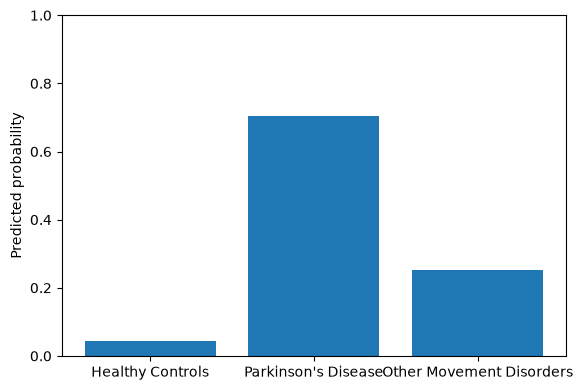

In [9]:
plt.figure(figsize=(6,4))
plt.bar(
    probabilities["Class"],
    probabilities["Probability"]
)
plt.ylabel("Predicted probability")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR/"baseline_prediction.png",
    dpi=300
)
plt.show()

## Selection of Simulation Scenarios

The hypothetical simulation scenarios were designed using the global SHAP analysis presented in the previous notebook.

Rather than modifying arbitrary variables, the simulations focus on the most influential questionnaire domains and wearable movement features identified by the final Full Multimodal XGBoost classifier. This approach ensures that each scenario explores clinically meaningful changes in variables that contributed substantially to the model predictions.

Four progressively complex scenarios are evaluated:

- **Scenario 1:** Increased non-motor symptom burden.
- **Scenario 2:** Increased questionnaire severity.
- **Scenario 3:** Increased motor impairment.
- **Scenario 4:** Combined clinical deterioration.

Each scenario modifies only a predefined subset of variables while keeping all remaining participant characteristics unchanged. The resulting prediction probabilities are then compared with the baseline prediction to evaluate the sensitivity of the model.

## Scenario 1: Increased Non-Motor Symptom Burden

The first hypothetical scenario investigates how the final Full Multimodal XGBoost classifier responds to an increase in the participant's non-motor symptom burden.

Clinically meaningful questionnaire domain scores are increased while all remaining demographic characteristics and wearable movement features remain unchanged.

The resulting prediction probabilities are compared with the baseline prediction to evaluate the sensitivity of the model to worsening non-motor symptoms.

In [10]:
scenario1 = participant.copy()
scenario1["sleep_fatigue_count"] += 2
scenario1["gastrointestinal_count"] += 1
scenario1["depression_anxiety_count"] += 2
scenario1["pain_count"] += 1

In [11]:
scenario1["sleep_fatigue_count"] = np.clip(
    scenario1["sleep_fatigue_count"] + 2,
    0,
    4,
)

In [12]:
#Predict again 
scenario1_prob = model.predict_proba(
    scenario1[model.feature_names_in_]
)[0]

In [13]:
comparison = pd.DataFrame({
    "Class":[
        "Healthy Controls",
        "Parkinson's Disease",
        "Other Movement Disorders"
    ],
    "Baseline":baseline_probabilities,
    "Scenario 1":scenario1_prob
})
comparison

,Class,Baseline,Scenario 1
0,Healthy Controls,0.043458,0.043458
1,Parkinson's Disease,0.703523,0.703523
2,Other Movement Disorders,0.253019,0.253019


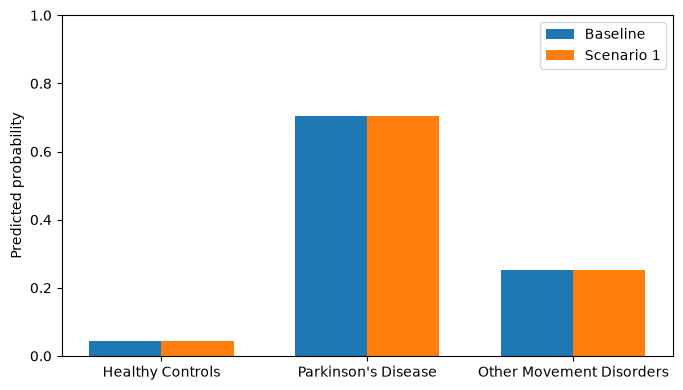

In [14]:
x = np.arange(3)
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(
    x-width/2,
    baseline_probabilities,
    width,
    label="Baseline"
)
plt.bar(
    x+width/2,
    scenario1_prob,
    width,
    label="Scenario 1"
)
plt.xticks(
    x,
    comparison["Class"]
)
plt.ylabel("Predicted probability")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR/"scenario1_questionnaire.png",
    dpi=300
)
plt.show()

### Scenario 1 Summary

Scenario 1 evaluated the effect of increasing the participant's aggregated non-motor symptom-domain counts while preserving all demographic characteristics and wearable movement features.

For the selected participant, the simulated modifications did not alter the predicted probability distribution. The probabilities for Healthy Controls, Parkinson's Disease, and Other Movement Disorders remained unchanged at **0.043**, **0.704**, and **0.253**, respectively.

This result suggests that the aggregated symptom-domain counts alone had little influence on the prediction for this participant. Instead, the final Full Multimodal XGBoost classifier appeared to rely more heavily on other sources of information, including individual questionnaire responses and wearable movement features. The absence of probability changes further highlights that the proposed framework integrates multiple complementary modalities rather than depending on a single group of variables.

## Scenario 2: Increased Questionnaire Severity

The second simulation investigates the effect of worsening individual questionnaire responses that were identified among the most influential predictors during the global SHAP analysis.

Unlike Scenario 1, which modified aggregated symptom-domain counts, this scenario directly increases selected questionnaire responses while preserving all wearable movement features and demographic characteristics.

The simulated changes represent a hypothetical increase in symptom severity and are intended solely to evaluate the sensitivity of the trained machine learning model.

In [15]:
# SCENARIO 2
# Increased questionnaire severity
scenario2 = participant.copy()
questions = [
    "Q25",
    "Q02",
    "Q05",
    "Q01",
    "Q08",
]
for question in questions:
    scenario2[question] = np.clip(
        scenario2[question] + 1,
        0,
        4,
    )
scenario2_prob = model.predict_proba(
    scenario2[model.feature_names_in_]
)[0]

In [16]:
comparison2 = pd.DataFrame({
    "Class":[
        "Healthy Controls",
        "Parkinson's Disease",
        "Other Movement Disorders"
    ],
    "Baseline":baseline_probabilities,
    "Scenario 2":scenario2_prob
})
comparison2

,Class,Baseline,Scenario 2
0,Healthy Controls,0.043458,0.008641
1,Parkinson's Disease,0.703523,0.916938
2,Other Movement Disorders,0.253019,0.074420


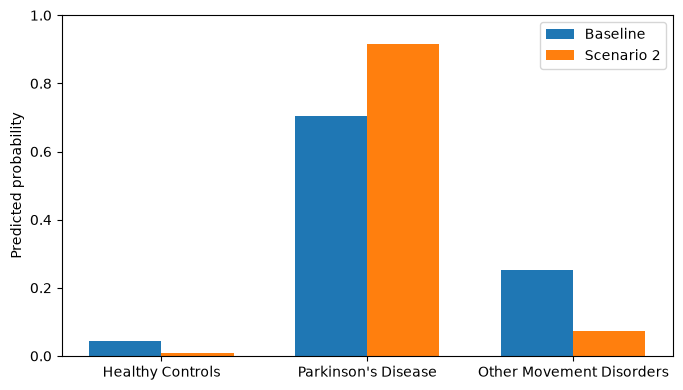

In [17]:
x = np.arange(3)
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(
    x-width/2,
    baseline_probabilities,
    width,
    label="Baseline",
)
plt.bar(
    x+width/2,
    scenario2_prob,
    width,
    label="Scenario 2",
)
plt.xticks(
    x,
    comparison2["Class"],
)
plt.ylabel("Predicted probability")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR/"scenario2_questionnaire.png",
    dpi=300,
)
plt.show()

### Scenario 2 Summary

Scenario 2 simulated an increase in the severity of selected questionnaire responses identified among the most influential predictors in the global SHAP analysis.

Compared with the baseline prediction, the probability of Parkinson's Disease increased substantially from **0.704** to **0.917**, while the probabilities assigned to Healthy Controls and Other Movement Disorders decreased from **0.043** to **0.009** and from **0.253** to **0.074**, respectively.

This scenario produced the largest probability shift among the individual simulations, indicating that specific questionnaire responses contributed strongly to the model's decision-making process for this participant. The findings are consistent with the global SHAP analysis, where several questionnaire variables ranked among the most influential predictors.

Although the predicted diagnostic class remained unchanged, the model became considerably more confident in its Parkinson's Disease prediction following the simulated increase in questionnaire severity.

## Scenario 3: Increased Motor Impairment

The third simulation investigates the influence of wearable movement features on the model predictions.

The modified variables correspond to the highest-ranked wearable features identified in the global SHAP analysis. Each selected feature is increased by one standard deviation computed from the complete processed dataset, representing a clinically plausible increase in movement abnormality while preserving all demographic variables and questionnaire responses.

The resulting prediction probabilities are compared with the baseline prediction to evaluate the sensitivity of the proposed framework to wearable movement information alone.

In [24]:
# SCENARIO 3
# Increased motor impairment
scenario3 = participant.copy()
motor_features = [
    "HoldWeight_RightWrist_gyro_y_dominant_frequency",
    "CrossArms_RightWrist_gyro_y_spectral_centroid",
    "LiftHold_Left_AccX_IQR",
    "TouchIndex_RightWrist_acc_magnitude_spectral_centroid",
    "CrossArms_Left_GyroMag_Min",
]
for feature in motor_features:
    std = dataset[feature].std()
    scenario3[feature] += std
    scenario3_prob = model.predict_proba(
    scenario3[model.feature_names_in_]
)[0]


In [25]:
comparison3 = pd.DataFrame({
    "Class":[
        "Healthy Controls",
        "Parkinson's Disease",
        "Other Movement Disorders"
    ],
    "Baseline":baseline_probabilities,
    "Scenario 3":scenario3_prob
})
comparison3

,Class,Baseline,Scenario 3
0,Healthy Controls,0.043458,0.048420
1,Parkinson's Disease,0.703523,0.783849
2,Other Movement Disorders,0.253019,0.167731


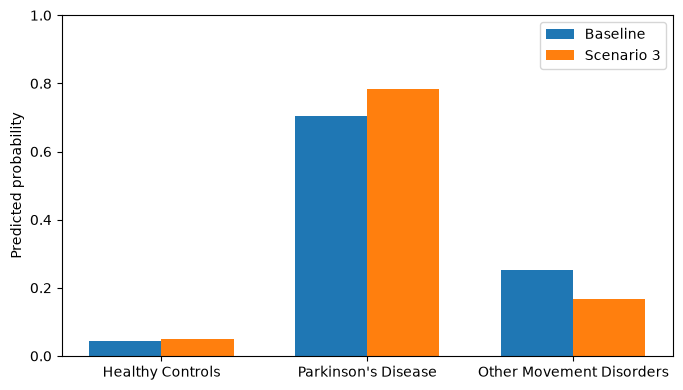

In [26]:
x = np.arange(3)
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(
    x-width/2,
    baseline_probabilities,
    width,
    label="Baseline"
)
plt.bar(
    x+width/2,
    scenario3_prob,
    width,
    label="Scenario 3"
)
plt.xticks(
    x,
    comparison3["Class"]
)
plt.ylabel("Predicted probability")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "scenario3_motor_impairment.png",
    dpi=300,
)
plt.show()

### Scenario 3 Summary

Scenario 3 investigated the effect of modifying the wearable movement features identified as the most influential motor predictors in the global SHAP analysis.

Compared with the baseline prediction, the probability of Parkinson's Disease increased from **0.704** to **0.784**, whereas the probability assigned to Other Movement Disorders decreased from **0.253** to **0.168**. The probability of Healthy Controls remained low, increasing only slightly from **0.043** to **0.048**.

These results indicate that wearable-derived movement features provide meaningful discriminatory information and increase the model's confidence in its Parkinson's Disease prediction. However, the probability shift was smaller than that observed in Scenario 2, suggesting that, for this participant, the questionnaire variables exerted a stronger influence than the wearable features when considered independently.

Overall, this scenario demonstrates that wearable movement characteristics complement questionnaire information within the proposed multimodal framework.

## Scenario 4: Combined Clinical Deterioration

The final simulation combines the modifications introduced in the previous scenarios to represent a hypothetical overall deterioration of the participant's clinical profile.

The participant simultaneously exhibits:

- increased non-motor symptom burden;
- worsening questionnaire responses identified as highly influential by the global SHAP analysis;
- increased abnormalities in the most important wearable movement features.

This scenario evaluates the cumulative effect of multimodal deterioration on the predicted class probabilities and illustrates how the proposed framework integrates information from multiple data sources.

In [27]:
# SCENARIO 4
# Combined clinical deterioration
scenario4 = participant.copy()
# Symptom domains
scenario4["sleep_fatigue_count"] = np.clip(
    scenario4["sleep_fatigue_count"] + 2,
    0,
    4,
)
scenario4["gastrointestinal_count"] = np.clip(
    scenario4["gastrointestinal_count"] + 1,
    0,
    4,
)
scenario4["depression_anxiety_count"] = np.clip(
    scenario4["depression_anxiety_count"] + 2,
    0,
    4,
)
scenario4["pain_count"] = np.clip(
    scenario4["pain_count"] + 1,
    0,
    4,
)
# Individual questionnaire items
questions = [
    "Q25",
    "Q02",
    "Q05",
    "Q01",
    "Q08",
]
for question in questions:
    scenario4[question] = np.clip(
        scenario4[question] + 1,
        0,
        4,
    )
# Wearable features
for feature in motor_features:
    scenario4[feature] += dataset[feature].std()
# Prediction
scenario4_prob = model.predict_proba(
    scenario4[model.feature_names_in_]
)[0]

In [28]:
comparison4 = pd.DataFrame({
    "Class":[
        "Healthy Controls",
        "Parkinson's Disease",
        "Other Movement Disorders"
    ],
    "Baseline":baseline_probabilities,
    "Scenario 4":scenario4_prob
})
comparison4

,Class,Baseline,Scenario 4
0,Healthy Controls,0.043458,0.008914
1,Parkinson's Disease,0.703523,0.945890
2,Other Movement Disorders,0.253019,0.045196


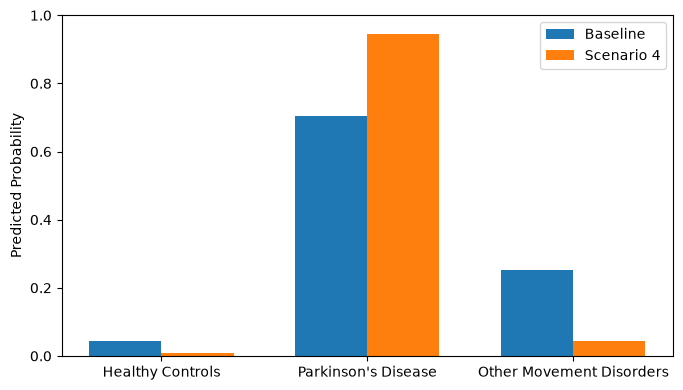

In [29]:
x = np.arange(3)
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(
    x-width/2,
    baseline_probabilities,
    width,
    label="Baseline",
)
plt.bar(
    x+width/2,
    scenario4_prob,
    width,
    label="Scenario 4",
)
plt.xticks(
    x,
    comparison4["Class"],
)
plt.ylabel("Predicted Probability")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "scenario4_combined_deterioration.png",
    dpi=300,
)
plt.show()

### Scenario 4 Summary

Scenario 4 combined the modifications introduced in the previous simulations by simultaneously increasing non-motor symptom burden, worsening the most influential questionnaire responses, and modifying the highest-ranked wearable movement features identified through the global SHAP analysis.

Compared with the baseline prediction, the probability assigned to Parkinson's Disease increased from **0.704** to **0.946**, while the probabilities associated with Healthy Controls and Other Movement Disorders decreased from **0.043** to **0.009** and from **0.253** to **0.045**, respectively.

Among all simulated scenarios, Scenario 4 produced the largest overall shift in the predicted probability distribution, demonstrating the cumulative contribution of multiple data modalities to the final prediction. Although the predicted diagnostic class remained unchanged, the model became substantially more confident in classifying the participant as having Parkinson's Disease.

These findings illustrate the multimodal nature of the proposed framework, where questionnaire responses and wearable movement features provide complementary information that jointly influences the final prediction. The combined simulation therefore represents the strongest hypothetical evidence supporting the model's Parkinson's Disease prediction for the selected participant.

## Comparison Across Simulation Scenarios

The probability distributions obtained from the baseline prediction and the four hypothetical simulation scenarios are summarized below.

Comparing all scenarios simultaneously provides an overview of how progressively modifying questionnaire responses, non-motor symptom burden, and wearable movement characteristics influences the predictions generated by the final Full Multimodal XGBoost classifier.

In [30]:
# COMPARISON OF ALL SCENARIOS
scenario_summary = pd.DataFrame({

    "Scenario":[
        "Baseline",
        "Scenario 1: Non-Motor Symptoms",
        "Scenario 2: Questionnaire ",
        "Scenario 3: Wearable",
        "Scenario 4: Combined",
    ],

    "Healthy Controls":[
        baseline_probabilities[0],
        scenario1_prob[0],
        scenario2_prob[0],
        scenario3_prob[0],
        scenario4_prob[0],
    ],

    "Parkinson's Disease":[
        baseline_probabilities[1],
        scenario1_prob[1],
        scenario2_prob[1],
        scenario3_prob[1],
        scenario4_prob[1],
    ],

    "Other Movement Disorders":[
        baseline_probabilities[2],
        scenario1_prob[2],
        scenario2_prob[2],
        scenario3_prob[2],
        scenario4_prob[2],
    ],

})

scenario_summary = scenario_summary.round(3)

scenario_summary

,Scenario,Healthy Controls,Parkinson's Disease,Other Movement Disorders
0,Baseline,0.043,0.704,0.253
1,Scenario 1: Non-Motor Symptoms,0.043,0.704,0.253
2,Scenario 2: Questionnaire,0.009,0.917,0.074
3,Scenario 3: Wearable,0.048,0.784,0.168
4,Scenario 4: Combined,0.009,0.946,0.045


In [31]:
scenario_summary.to_csv(
    TABLES_DIR / "what_if_simulation_summary.csv",
    index=False,
)

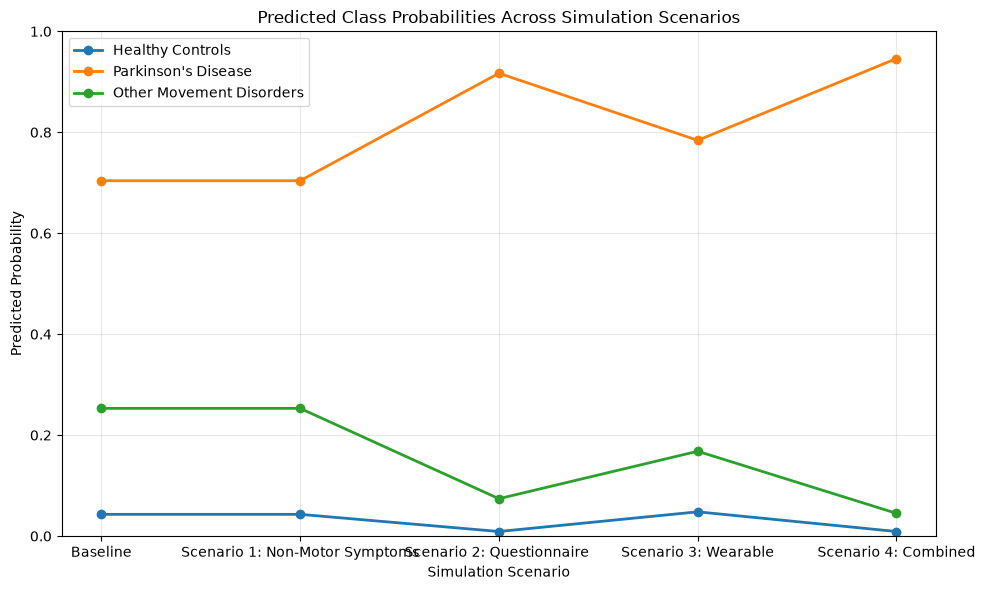

In [32]:
plt.figure(figsize=(10,6))

plt.plot(
    scenario_summary["Scenario"],
    scenario_summary["Healthy Controls"],
    marker="o",
    linewidth=2,
    label="Healthy Controls",
)

plt.plot(
    scenario_summary["Scenario"],
    scenario_summary["Parkinson's Disease"],
    marker="o",
    linewidth=2,
    label="Parkinson's Disease",
)

plt.plot(
    scenario_summary["Scenario"],
    scenario_summary["Other Movement Disorders"],
    marker="o",
    linewidth=2,
    label="Other Movement Disorders",
)

plt.ylim(0,1)

plt.ylabel("Predicted Probability")

plt.xlabel("Simulation Scenario")

plt.title(
    "Predicted Class Probabilities Across Simulation Scenarios"
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "what_if_simulation_summary.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## What-if Simulation Summary

The scenario-based simulations demonstrated that the final Full Multimodal XGBoost classifier responds differently to distinct types of clinically meaningful hypothetical modifications.

Increasing aggregated non-motor symptom-domain counts alone did not alter the predicted probabilities for the selected participant, suggesting that these summary variables had limited influence when considered independently. In contrast, modifying the individual questionnaire responses identified through the global SHAP analysis produced a substantial increase in the probability of Parkinson's Disease, indicating that these variables contributed more strongly to the model's decision-making process.

The wearable movement simulation also increased the model's confidence in its Parkinson's Disease prediction, although its effect was more moderate than that observed for the questionnaire variables. Finally, combining questionnaire responses, symptom-domain counts, and wearable movement features produced the largest probability shift, demonstrating how the proposed multimodal framework integrates complementary sources of information to generate its final prediction.

Overall, these simulations illustrate the sensitivity of the proposed framework to clinically meaningful changes in participant characteristics while reinforcing the value of multimodal data integration. The simulation workflow developed in this notebook provides the computational foundation for the interactive What-if Simulator implemented in the accompanying Streamlit prototype.

The simulated scenarios are intended solely to explore the behavior of the trained machine learning model. They should not be interpreted as evidence of disease progression, treatment response, or causal relationships between individual variables and Parkinson's disease.

The simulated scenarios are intended exclusively to explore the behavior of the trained machine learning model. They should not be interpreted as evidence of disease progression, treatment response, or causal relationships between individual variables and Parkinson's disease.